In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch.nn as nn 
import torch.optim as optim
import cv2

In [3]:
image_dir = "../dataset/image-dataset/train"

for label, class_dir in enumerate(os.listdir(image_dir)):
    print(label, class_dir)

0 Cat
1 Dog
2 Female
3 Male


In [4]:
class ImageDataSet(Dataset):
    def __init__(self, image_dir, transform=None):
        super().__init__()

        self.image_dir = image_dir
        self.image_paths = []   # ../dataset/image-dataset/train\Cat\cat_10001.jpg
        self.labels = []        # 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3.....
        self.class_name = {}    # {0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}
        self.transform = transform

        for label, class_dir in enumerate(os.listdir(image_dir)):
            self.class_name[label] = class_dir
            class_path = os.path.join(image_dir, class_dir) # full path for class folder
            for image_name in os.listdir(class_path): 
                self.image_paths.append(os.path.join(class_path, image_name))
                self.labels.append(label)
 
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)
            
        return image, label


In [5]:
ImageDataSet(image_dir)

In [6]:
# before traing need to convert resize and convert tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [8]:
transform

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

In [9]:
train_image_dir = "../dataset/image-dataset/train"
test_image_dir = "../dataset/image-dataset/test"

train_image_dataset = ImageDataSet(image_dir=train_image_dir, transform=transform)
test_image_dataset = ImageDataSet(image_dir=test_image_dir, transform=transform)

In [10]:
len(train_image_dataset), len(test_image_dataset)

(29956, 460)

In [13]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=64, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=64, shuffle=True)

In [14]:
print(train_image_dataset.class_name)
print(test_image_dataset.class_name)

{0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}
{0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}


In [15]:
counter = 0
for images, labels in train_image_loader:
    print(images.shape, labels.shape)
    counter += 1
    if counter == 10:
        break

torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])
torch.Size([64, 3, 128, 128]) torch.Size([64])


In [16]:
print(train_image_dataset.class_name)
print(test_image_dataset.class_name)

{0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}
{0: 'Cat', 1: 'Dog', 2: 'Female', 3: 'Male'}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.827451..1.0].


image shape =====>  (3, 128, 128)
label ---> 0
Class Name Cat
(128, 128, 3)


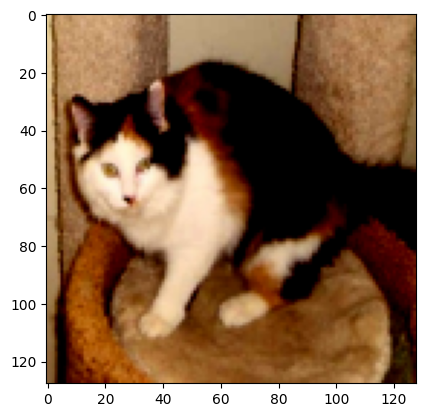

In [20]:
for images, labels in train_image_loader:
  # get first image from a batch 
  img = images[0].numpy()
  print("image shape =====> ", img.shape)
  # get first label from a batch
  label = labels[0].item()
  print("label --->", label)
  print("Class Name", train_image_dataset.class_name[label])
  img = np.transpose(img, (1,2,0))
  print(img.shape)
  plt.imshow(img, vmin=0, vmax=255)
  break

#### Convolutional Neural Networks (CNN)
- Image -> Feature Detector = we get Feature map
- We create many feature map to obtain our convolutional layer
- User ReLU activation for breakdown image linearity
- Feature map -> max pooling -> we get pooled feature map
- Pooled feature map -> Flattening
- Flattening -> Input -> Fully Connected Layer -> Output Layer

- Image → Conv2d + BatchNorm + ReLU + MaxPool → Flatten → Fully Connected Layers → Output Classes

In [ ]:
# Make CNN model
class CNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CNNModel, self).__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes

        # Image to Feature Map
        self.conv_layer = nn.Sequential(
            # Conv Layer 1:(input_channels=3, output_channels=32, kernel_size=3)
            # i have use input channel because its RGB image, 1 for gray scale image,
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2:(input_channels=3, output_channels=32, kernel_size=3) 
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 3:(input_channels=3, output_channels=32, kernel_size=3) 
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 4:(input_channels=3, output_channels=32, kernel_size=3) 
            nn.Conv2d(128, 256, 3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)

        )

        self.to_linear = None
        # Automatically get flattened size
        self._get_conv_output(self.input_dim)

        self.fully_connected_layer = nn.Sequential(
            # nn.Linear(in_features, out_features)
            nn.Linear(self.to_linear, 512),
            nn.ReLU(), 
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, self.num_classes)
        )



    def _get_conv_output(self, input_dim=128):
        with torch.no_grad():
            # batch = 1, Channels = 3, size=(height, width)
            dummy_input = torch.zeros(1, 3, input_dim, input_dim)
            output = self.conv_layer(dummy_input)
            self.to_linear = output.view(1, -1).size(1)


    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1) # flatten 
        x = self.fully_connected_layer(x)
        return x

    

In [35]:
"""
output = torch.randn(2, 3, 4, 4)  # Shape: [2, 3, 4, 4]
print("Original shape:", output.shape)

features = output.view(1, -1).size(1)
print("Features:", features)
ক্যালকুলেশন:

Original: [2, 3, 4, 4] → total elements = 2 * 3 * 4 * 4 = 96

After view(1, -1): shape হয় [1, 96]

.size(1) → 96
"""

'\noutput = torch.randn(2, 3, 4, 4)  # Shape: [2, 3, 4, 4]\nprint("Original shape:", output.shape)\n\nfeatures = output.view(1, -1).size(1)\nprint("Features:", features)\nক্যালকুলেশন:\n\nOriginal: [2, 3, 4, 4] → total elements = 2 * 3 * 4 * 4 = 96\n\nAfter view(1, -1): shape হয় [1, 96]\n\n.size(1) → 96\n'

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [37]:
model = CNNModel(input_dim=128, num_classes=4).to(device)
model

CNNModel(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [38]:
# loass
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [39]:
len(train_image_loader)

469

In [40]:
# Training
epochs = 2

for epoch in range(epochs):
    model.train()
    running_loss = 0.00

    for images, labels in train_image_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        # pass image batch
        prediction = model(images)
        loss = criterion(prediction, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/ {epochs}, Loss: {running_loss/len(train_image_loader)}")


d:\machine-learning\computer vision\venv\Lib\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
d:\machine-learning\computer vision\venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/ 2, Loss: 0.7170770347499644
Epoch 2/ 2, Loss: 0.4382916350545151


In [1]:
for images, labels in test_image_loader:
    print(labels.shape)

NameError: name 'test_image_loader' is not defined

In [ ]:
# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_image_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test accuracy is : {100 * correct/total:.2f}")    

In [ ]:
class ImageClassifier:
    def __init__(self, model_path, class_name):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = CNNModel(input_dim=128, num_classes=4).to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()
        self.class_name = class_name
        # before traing need to convert resize and convert tensor
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def predict(self, image_path):
        image = Image.open(image_path).convert("RGB")
        # pytorch input need 4D (Batch, Channels, Height, Width)
        input_tensor = self.transform(image).unsqueeze(0).to(self.device) # unsqueeze add new dimention, add batch = 1
        with torch.no_grad():
            output = self.model(input_tensor)
            _, predicted = torch.max(output, 1)
        
        predicted_class = self.class_name[predicted.item()]
        img = cv2.imread(image_path)
        # Coordinate (10, 30)
        cv2.putText(img, predicted_class, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        cv2.imwrite("output_image.jpg", img)
        return predicted_class

        

In [ ]:
classifier = ImageClassifier("path/model.pth", train_image_dataset.class_name)
predicted_class = classifier.predict("path/test/cat_1.png")
print("Predicted class is: ", predicted_class)